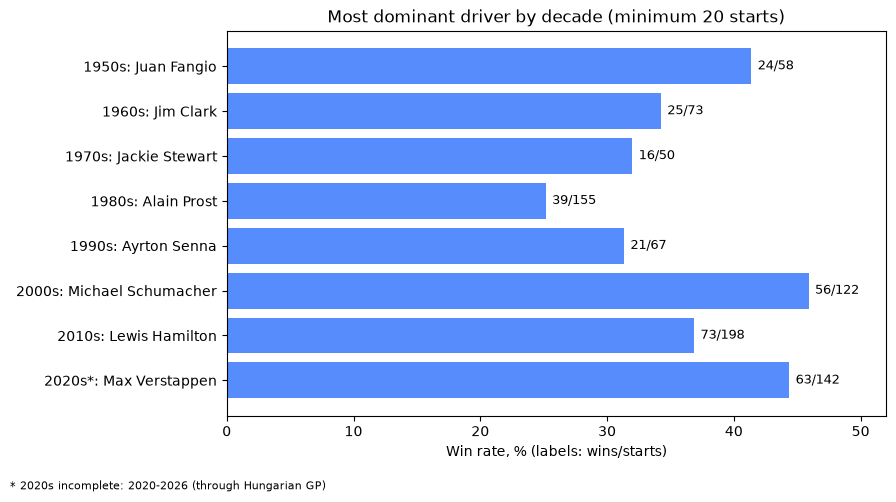

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/q1_dominant_drivers.csv")
top1 = df[df["rank_in_decade"] == 1].copy()

star = top1["decade"].apply(lambda d: "*" if d == 2020 else "")
top1["label"] = top1["decade"].astype(str) + "s" + star + ": " + top1["driver_name"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top1["label"], top1["win_rate_pct"])
ax.invert_yaxis()

for bar, wins, starts in zip(bars, top1["wins"], top1["starts"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{wins}/{starts}", va="center", fontsize=9)

ax.set_xlim(0, 52)
ax.set_xlabel("Win rate, % (labels: wins/starts)")
ax.set_title("Most dominant driver by decade (minimum 20 starts)")
fig.text(0.01, 0.01, "* 2020s incomplete: 2020-2026 (through Hungarian GP)", fontsize=8)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("../charts/q1_dominant_drivers.png", dpi=150)
plt.show()

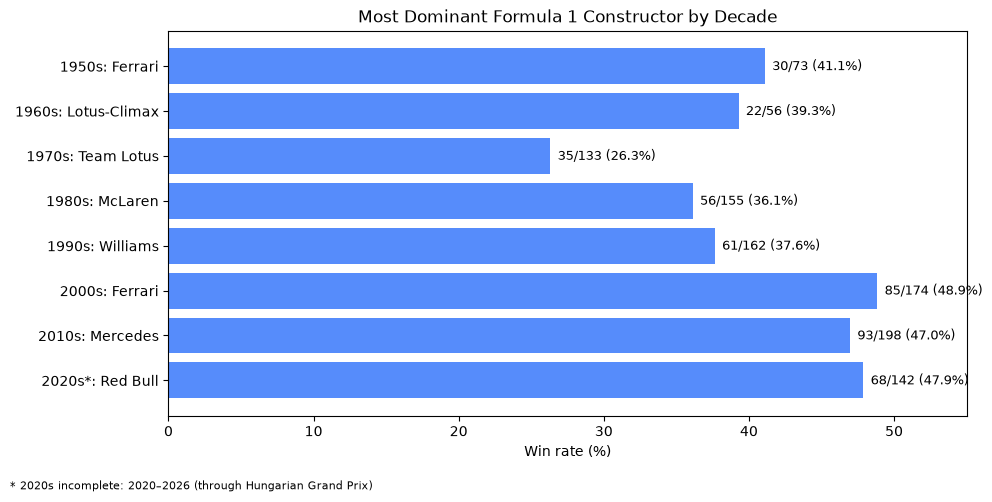

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/q2_constructor_dominance.csv")

top1 = df[df["rank_in_decade"] == 1].copy()

star = top1["decade"].apply(lambda d: "*" if d == 2020 else "")

top1["label"] = (
    top1["decade"].astype(str)
    + "s"
    + star
    + ": "
    + top1["constructor_name"]
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    top1["label"],
    top1["win_rate_pct"]
)

ax.invert_yaxis()

for bar, wins, races in zip(
    bars,
    top1["wins"],
    top1["races"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{wins}/{races} ({bar.get_width():.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 55)

ax.set_xlabel("Win rate (%)")
ax.set_title("Most Dominant Formula 1 Constructor by Decade")

fig.text(
    0.01,
    0.01,
    "* 2020s incomplete: 2020–2026 (through Hungarian Grand Prix)",
    fontsize=8
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(
    "../charts/q2_constructor_dominance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

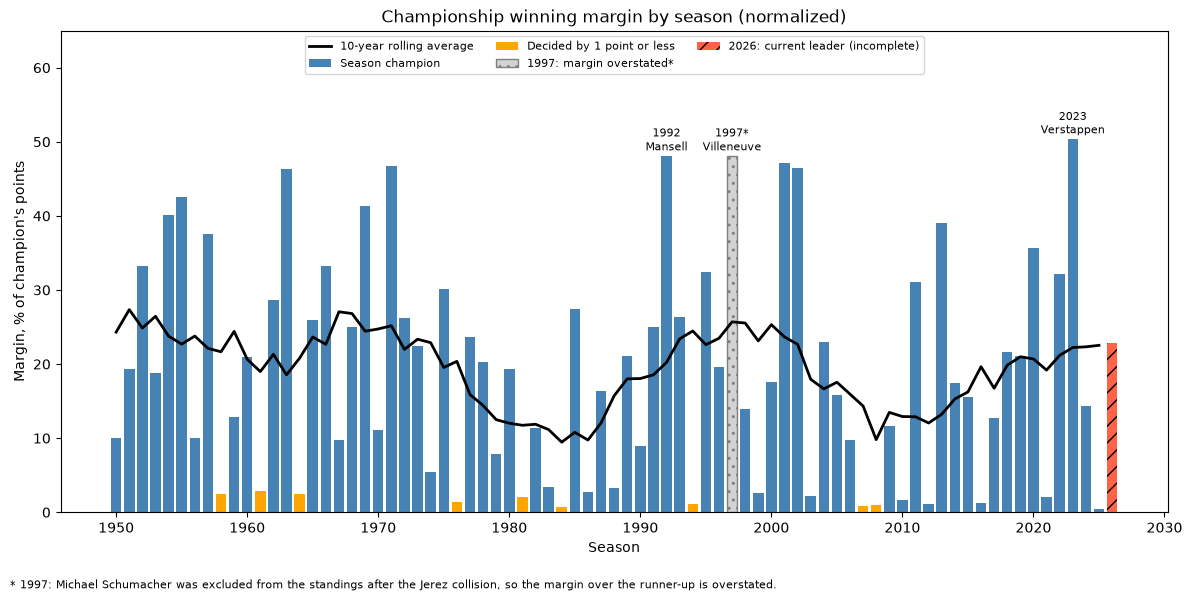

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/q3_season_champions.csv")
complete = df[df["year"] < 2026].copy()
current = df[df["year"] == 2026]

close = complete["margin"] <= 1           # decided by 1 point or less
anomaly = complete["year"] == 1997        # Schumacher excluded from standings
regular = ~close & ~anomaly

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(complete.loc[regular, "year"], complete.loc[regular, "margin_pct"],
       color="steelblue", label="Season champion")
ax.bar(complete.loc[close, "year"], complete.loc[close, "margin_pct"],
       color="orange", label="Decided by 1 point or less")
ax.bar(complete.loc[anomaly, "year"], complete.loc[anomaly, "margin_pct"],
       color="lightgray", edgecolor="gray", hatch="..",
       label="1997: margin overstated*")
ax.bar(current["year"], current["margin_pct"], color="tomato", hatch="//",
       label="2026: current leader (incomplete)")

trend = (complete.set_index("year")["margin_pct"]
         .rolling(10, center=True, min_periods=5).mean())
ax.plot(trend.index, trend.values, color="black", linewidth=2,
        label="10-year rolling average")

# Label the 3 biggest margins (1997 gets an asterisk)
for _, row in complete.nlargest(3, "margin_pct").iterrows():
    mark = "*" if row["year"] == 1997 else ""
    ax.annotate(f"{int(row['year'])}{mark}\n{row['driver_name'].split()[-1]}",
                (row["year"], row["margin_pct"]),
                textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=8)

ax.set_ylim(0, 65)
ax.set_xlabel("Season")
ax.set_ylabel("Margin, % of champion's points")
ax.set_title("Championship winning margin by season (normalized)")
ax.legend(loc="upper center", ncol=3, fontsize=8)

fig.text(0.01, 0.01,
         "* 1997: Michael Schumacher was excluded from the standings after the Jerez collision, "
         "so the margin over the runner-up is overstated.",
         fontsize=8, ha="left")

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("../charts/q3_championship_margins.png", dpi=150, bbox_inches="tight")
plt.show()

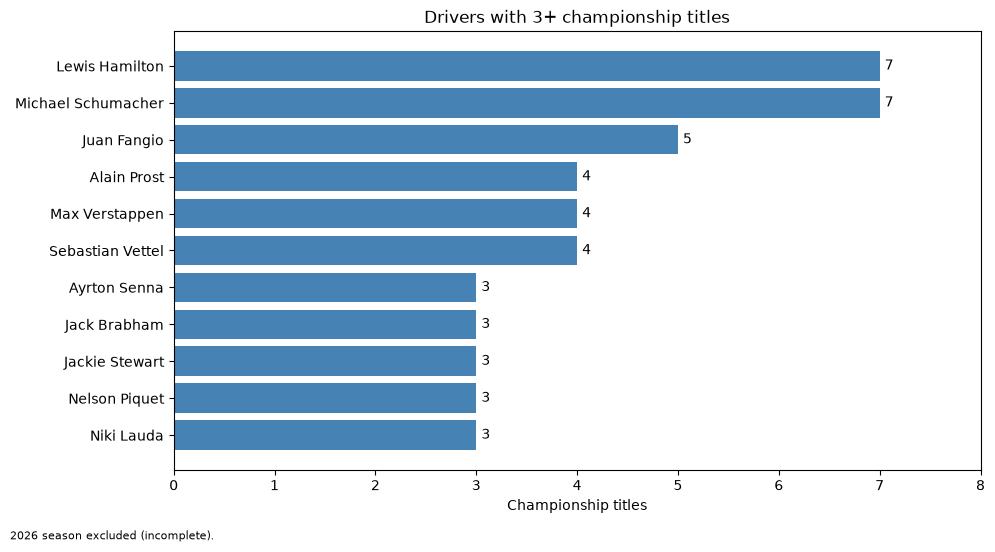

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/q3_titles_by_driver.csv")

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(df["driver_name"], df["titles"], color="steelblue")
ax.invert_yaxis()

for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            int(bar.get_width()), va="center")

ax.set_xlim(0, 8)
ax.set_xlabel("Championship titles")
ax.set_title("Drivers with 3+ championship titles")
fig.text(0.01, 0.01, "2026 season excluded (incomplete).", fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("../charts/q3_championship_titles.png", dpi=150, bbox_inches="tight")
plt.show()